In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import seaborn as sns

## SQL Connection & Querying

In [3]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv')
conn = sqlite3.connect('survey-data.sqlite')
df.to_sql('SURVEY_DATA', conn, if_exists='replace', index=False)

65437

In [8]:
%load_ext sql
%sql sqlite:///survey-data.sqlite
%config SqlMagic.autopandas = True

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [9]:
%sql SELECT * FROM SURVEY_DATA LIMIT 5

Running query in 'sqlite:///survey-data.sqlite'

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,None,None
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,None,None
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,None,None
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,None,None


In [44]:
%%sql 

SELECT Age, COUNT(*) as count
FROM SURVEY_DATA
GROUP BY Age
ORDER BY Age

Running query in 'sqlite:///survey-data.sqlite'

,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## SQL Querying With Visualisation

Q1: 60000, Q3: 250000, IQR: 190000, upper bound: 535000


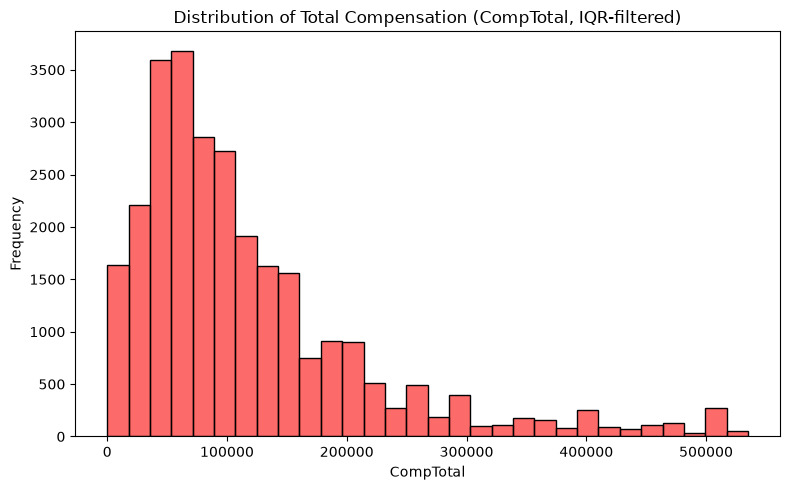

In [36]:
QUERY = "SELECT CompTotal FROM SURVEY_DATA"
df_comp = pd.read_sql_query(QUERY, conn)

Q1 = df_comp['CompTotal'].quantile(0.25)
Q3 = df_comp['CompTotal'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.0f}, Q3: {Q3:.0f}, IQR: {IQR:.0f}, upper bound: {upper_bound:.0f}")

df_comp_filtered = df_comp[df_comp['CompTotal'] <= upper_bound]

plt.figure(figsize=(8, 5))
plt.hist(df_comp_filtered['CompTotal'], bins=30, color="#FC1B1BA6", edgecolor='black')
plt.title('Distribution of Total Compensation (CompTotal, IQR-filtered)')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

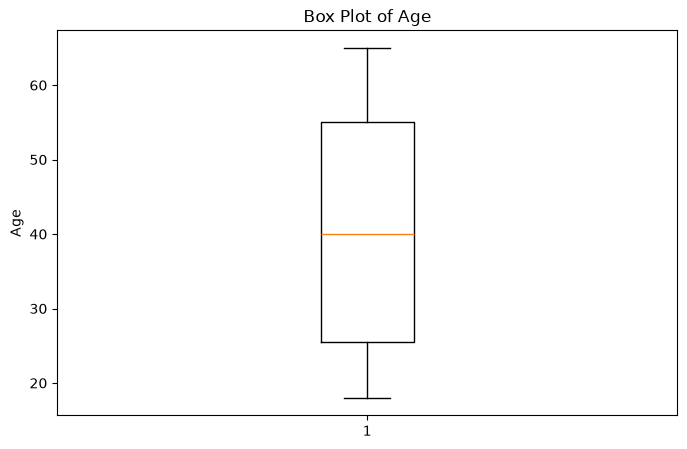

In [53]:
QUERY = "SELECT Age, COUNT(Age) FROM SURVEY_DATA GROUP BY Age"
df = pd.read_sql_query(QUERY, conn)

df['Age'] = df['Age'].replace('25-34 years old', '30')
df['Age'] = df['Age'].replace('35-44 years old', '40')
df['Age'] = df['Age'].replace('18-24 years old', '21')
df['Age'] = df['Age'].replace('45-54 years old', '50')
df['Age'] = df['Age'].replace('55-64 years old', '60')
df['Age'] = df['Age'].replace('Under 18 years old', '18')
df['Age'] = df['Age'].replace('65 years or older', '65')
dfAge = df.drop(df[df['Age'] == 'Prefer not to say'].index)
dfAge['Age'] = dfAge['Age'].astype('int')

plt.figure(figsize=(8,5))
plt.boxplot(dfAge['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

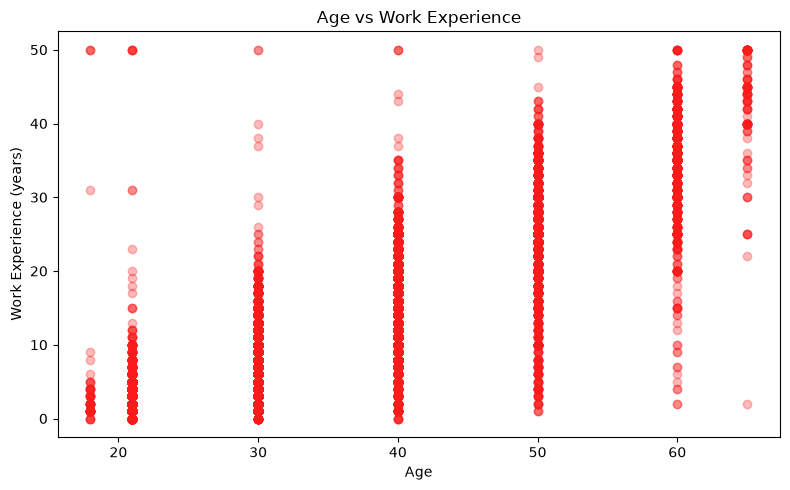

In [56]:
QUERY = "SELECT Age, WorkExp FROM SURVEY_DATA"
df = pd.read_sql_query(QUERY, conn)

# Clean Age: convert text brackets to numeric approximations (same mapping as before)
df['Age'] = df['Age'].replace('25-34 years old', '30')
df['Age'] = df['Age'].replace('35-44 years old', '40')
df['Age'] = df['Age'].replace('18-24 years old', '21')
df['Age'] = df['Age'].replace('45-54 years old', '50')
df['Age'] = df['Age'].replace('55-64 years old', '60')
df['Age'] = df['Age'].replace('Under 18 years old', '18')
df['Age'] = df['Age'].replace('65 years or older', '65')

# Drop respondents who skipped Age meaningfully or left WorkExp blank
dfAgeExp = df[df['Age'] != 'Prefer not to say'].dropna(subset=['Age', 'WorkExp']).copy()
dfAgeExp['Age'] = dfAgeExp['Age'].astype('int')

plt.figure(figsize=(8, 5))
plt.scatter(dfAgeExp['Age'], dfAgeExp['WorkExp'], alpha=0.3, color="#FC1B1BA6")
plt.title('Age vs Work Experience')
plt.xlabel('Age')
plt.ylabel('Work Experience (years)')
plt.tight_layout()
plt.show()

In [95]:
# Creating colour palette
import colorsys

def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')[:6]  # drop the alpha channel (A6) if present
    return tuple(int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4))

def red_shades(base_hex, n):
    r, g, b = hex_to_rgb(base_hex)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    lightness_values = np.linspace(0.85, 0.25, n)  # light -> dark, same hue/saturation throughout
    return [colorsys.hls_to_rgb(h, l_val, s) for l_val in lightness_values]

n_wedges = len(DB_Top_5)  # however many slices you're plotting — adjust to your actual variable
palette = red_shades("#FC1B1B", n_wedges)

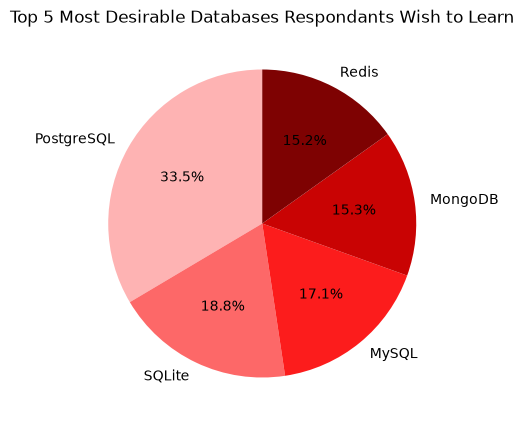

In [96]:
QUERY = "SELECT DatabaseWantToWorkWith FROM SURVEY_DATA"
df_comp = pd.read_sql_query(QUERY, conn)

DBtoWorkWith = df_comp['DatabaseWantToWorkWith'].dropna().str.split(';').explode()

count = DBtoWorkWith.value_counts()

DB_Top_5 = count.sort_values(ascending=False).head()

plt.figure(figsize=(8, 5), )
plt.pie(DB_Top_5, labels=DB_Top_5.index, autopct='%1.1f%%', startangle=90, colors=palette)
plt.title('Top 5 Most Desirable Databases Respondants Wish to Learn')
plt.show()

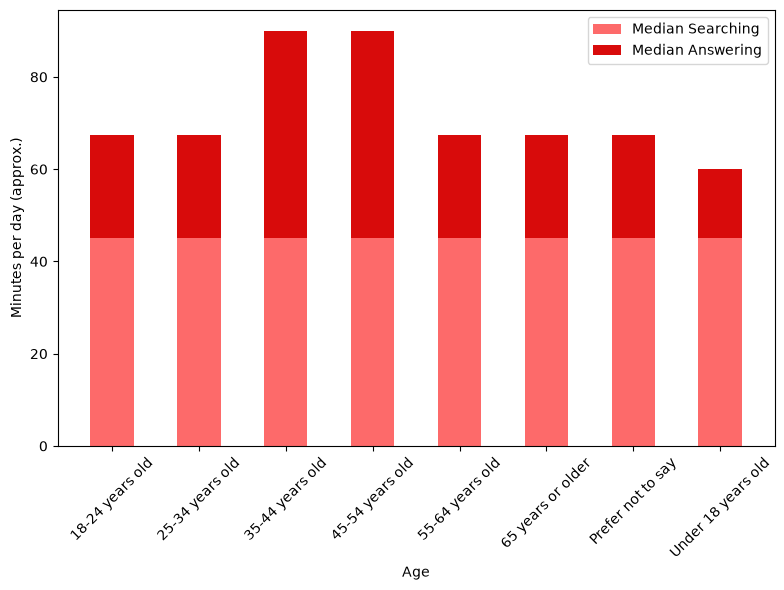

In [133]:
QUERY = "SELECT TimeSearching, TimeAnswering, Age FROM SURVEY_DATA"
df_comp = pd.read_sql_query(QUERY, conn)

time_searching_map = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150,
}

df_comp['TimeSearching_num'] = df_comp['TimeSearching'].map(time_searching_map)

time_answering_map = {
    'Less than 15 minutes a day': 7.5,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150,
}

df_comp['TimeAnswering_num'] = df_comp['TimeAnswering'].map(time_answering_map)

median_searching = df_comp.groupby('Age')['TimeSearching_num'].median()
median_answering = df_comp.groupby('Age')['TimeAnswering_num'].median()

plt.figure(figsize=(8, 6))
plt.bar(median_searching.index, median_searching, width=0.5, label='Median Searching', color="#FC1B1BA6")
plt.bar(median_answering.index, median_answering, width=0.5, bottom=median_searching, label='Median Answering', color="#D80B0BFF")
plt.xlabel('Age')
plt.ylabel('Minutes per day (approx.)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

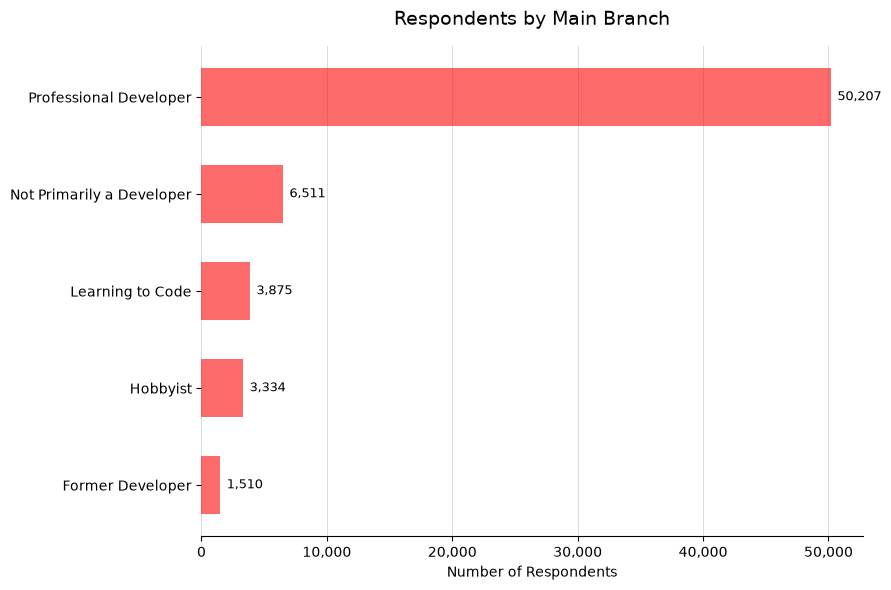

In [155]:
QUERY = "SELECT MainBranch FROM SURVEY_DATA"
df_comp = pd.read_sql_query(QUERY, conn)

df_comp['MainBranch'] = df_comp['MainBranch'].replace('I am a developer by profession', 'Professional Developer')
df_comp['MainBranch'] = df_comp['MainBranch'].replace('I am not primarily a developer, but I write code sometimes as part of my work/studies', 'Not Primarily a Developer')
df_comp['MainBranch'] = df_comp['MainBranch'].replace('I am learning to code', 'Learning to Code')
df_comp['MainBranch'] = df_comp['MainBranch'].replace('I code primarily as a hobby', 'Hobbyist')
df_comp['MainBranch'] = df_comp['MainBranch'].replace('I used to be a developer by profession, but no longer am', 'Former Developer')

MainBranch = df_comp['MainBranch'].value_counts()
MainBranch = MainBranch[::-1]  # largest bar at the top

MainBranch = df_comp['MainBranch'].value_counts()
MainBranch = MainBranch[::-1]  # largest bar at the top

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(MainBranch.index, MainBranch, height=0.6, color="#FC1B1BA6")

# Strip the box down to just the bottom axis line
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Light gridlines on the value axis, drawn behind the bars
ax.set_axisbelow(True)
ax.xaxis.grid(True, color='lightgray', linewidth=0.6)

# Format x-axis ticks with thousands separators (40000 -> 40,000)
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

# Direct value labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + MainBranch.max() * 0.01, bar.get_y() + bar.get_height() / 2,
             f'{int(width):,}', va='center', fontsize=9)

ax.set_title('Respondents by Main Branch', fontsize=14, pad=15)
ax.set_xlabel('Number of Respondents')
plt.tight_layout()
plt.show()